# Building an Image-Based Recommendation System and Search Engine with Deep Learning and Elasticsearch

### Setting up useful variabes

In [1]:
import os
## The base dir of the project
PROJECT_DIR = "/home/projects/IBRS/Image-Based-Recommendation-System/02 - ResNet and Elasticsearch/"

## The "etc" dir contains all the files not tracked in GitHub
ETC_DIR = os.path.join(PROJECT_DIR, "etc")

## The .zip of the dataset is provided in the repository, but it's unzipped in "etc"
DATASET_ZIP_FILE = os.path.join(PROJECT_DIR, "dataset.zip")
DATASET_DIR = os.path.join(ETC_DIR, "dataset")
DATASET_METADATA_TXT_FILE = os.path.join(DATASET_DIR, "metadata.txt")
DATASET_METADATA_JSON_FILE = os.path.join(DATASET_DIR, "metadata.json")
DATASET_METADATA_DIR = os.path.join(DATASET_DIR, "metadata")

### Unzip the dataset

In [2]:
import zipfile

if not os.path.exists(DATASET_DIR):
    with zipfile.ZipFile(DATASET_ZIP_FILE, 'r') as data:
        data.extractall(path=ETC_DIR)
else:
    print('[INFO] Dataset already unzipped')

### Generate a JSON metadata file from the TXT file

In [3]:
import json

metadata = []

if not os.path.exists(DATASET_METADATA_JSON_FILE):
    with open(DATASET_METADATA_TXT_FILE, 'r') as file :
        line = file.readline()
        while line:
            
            # read metadata of the current item
            item = eval(line.strip())
            
            metadata.append(item)
            
            # read the next line (next item)
            line = file.readline()
    
    with open(DATASET_METADATA_JSON_FILE, 'w') as file:
        json.dump(metadata, file)
else:
    print('[INFO] The JSON file already exists. Loading from disk')
    with open(DATASET_METADATA_JSON_FILE, 'r') as file:
        metadata = json.load(file)

[INFO] The JSON file already exists. Loading from disk


The metadata file contains a list of metadata, as shown in the following example

```json
[
  {
    "ID": 7541,
    "title": "Christina Gavioli",
    "slug": "christina-gavioli-3",
    "category": [
      "Fashion Women",
      "Women Blouse and Dress"
    ],
    "imPath": "images/Fashion Women/Women Blouse and Dress/CHRISTINA_GAVIOLI.jpg"
  },
]
```

## Create the Elasticsearch Mapping to index the Data

In this tutorial, I'm using Elasticsearch as the data store and the vector database. Elasticsearch can perform vector or similarity search using KNN.

```json
"image_features": {
    "type": "dense_vector",
    "dims": 2048,
    "index": true,
    "similarity": "cosine"
}
```
* `dims`: The dimension should be the actual dimension of the dense vectors.
* `index`: When ***true*** (the default value), ES can perform vector search. It then creates an HNSW (Hierarchical Navigable Small World) index that is used to perform vector search. When it is set to ***false***, ES stores vectors but does not perform vector search. Useful only for storing embeddings for external processing. 
* `similarity`: The default value is ***cosine***. It defines the similarity metric that ES will use for vector search. Other metrics: *dot_product*, *l2_norm*

Vector store is available from Elasticsearch version 8+. Here, I'm using version 9.1.8.

Doc: [approximate-knn-search](https://www.elastic.co/docs/deploy-manage/production-guidance/optimize-performance/approximate-knn-search).

In [4]:
# define the mapping
mapping = {
  "mappings": {
    "properties": {
      "ID": {
        "type": "integer"
      },
      "title": {
        "type": "text",
        "fields": {
          "keyword": {
            "type": "keyword"
          }
        }
      },
      "slug": {
        "type": "text",
        "fields": {
          "keyword": {
            "type": "keyword"
          }
        }
      },
      "category": {
        "type": "keyword"
      },
      "imPath": {
        "type": "keyword"
      },
      "image_features": {
        "type": "dense_vector",
        "dims": 2048,
        "index": True,
        "similarity": "cosine"
      }
    }
  }
}

### Create the mapping using the Elasticsearch Python API

Make sur your Elasticsearch instance is up and running.

You can use the docker command below to run Elasticsearch.

```shell
docker run -d --name elasticsearch -p 9200:9200 -e "discovery.type=single-node" -e "xpack.security.enabled=false" elasticsearch:9.1.8
```
The `xpack.security.enabled=false` property is used to disable security for local development. It allows connecting and interacting with 
Elasticsearch with http://localhost:9200 without authentication.

In [6]:
from elasticsearch import Elasticsearch

es = Elasticsearch("http://localhost:9200")

index_name = "items"

if not es.indices.exists(index=index_name):
    es.indices.create(index=index_name, body=mapping)
    print("[INFO] Mapping create.")

In [7]:
metadata[0]

{'ID': 7541,
 'title': 'Christina Gavioli',
 'slug': 'christina-gavioli-3',
 'category': ['Fashion Women', 'Women Blouse and Dress'],
 'imPath': 'images/Fashion Women/Women Blouse and Dress/CHRISTINA_GAVIOLI.jpg'}

### Indexing the data in Elasticsearch

In [8]:
from elasticsearch.helpers import bulk

actions = [
    {
        "_index": index_name,
        "_id": item["ID"],
        "_source": item
    }
    for item in metadata
]

bulk(es, actions)
print("[INFO] Document indexed successfully")

[INFO] Document indexed successfully


In [9]:
es.search()

ObjectApiResponse({'took': 181, 'timed_out': False, '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0}, 'hits': {'total': {'value': 1655, 'relation': 'eq'}, 'max_score': 1.0, 'hits': [{'_index': 'items', '_id': '2923', '_score': 1.0, '_source': {'ID': 2923, 'title': 'Crème anti rondeurs aux extraits de plantes Clarins Paris', 'slug': 'creme-anti-rondeurs-aux-extraits-de-plantes-clarins-paris', 'category': ['Fashion Women', 'Women Perfume and Beauty'], 'imPath': 'images/Fashion Women/Women Perfume and Beauty/DSC_0404.jpg'}}, {'_index': 'items', '_id': '2934', '_score': 1.0, '_source': {'ID': 2934, 'title': 'Lait éclaircissant QEI+ Paris ', 'slug': 'lait-eclaircissant-qei-paris', 'category': ['Fashion Women', 'Women Perfume and Beauty'], 'imPath': 'images/Fashion Women/Women Perfume and Beauty/DSC_0406.jpg'}}, {'_index': 'items', '_id': '2935', '_score': 1.0, '_source': {'ID': 2935, 'title': 'Lait hydratant La Beauté ', 'slug': 'lait-hydratant-la-beaute', 'category': ['F

## Extract Embeddings Using ResNet50

In [10]:
from tensorflow.keras.applications import resnet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import Model

import numpy as np

# Initialize the ResNet model with the Imagenet weights. You can use resnet.summary() to see the model structure
resnet = resnet50.ResNet50(weights='imagenet')

# create a submodel from the ResNet model
resnet_embeddings_extractor = Model(inputs=resnet.inputs, outputs=resnet.get_layer('avg_pool').output)

# uncomment the code below to see the resnet_embeddings_extractor structure
#resnet_embeddings_extractor.summary()

2026-01-30 17:59:20.113306: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-30 17:59:20.268112: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-30 17:59:20.863426: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-30 17:59:22.348493: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [13]:
def load_image(path):
    img = image.load_img(path, target_size=(224, 224))
    x = image.img_to_array(img)
    return x

def preprocess_batch(img_arrays):
    batch = np.stack(img_arrays, axis=0)
    return preprocess_input(batch)

def extract_embeddings_batch(paths):
    imgs = [load_image(path) for path in paths]
    batch = preprocess_batch(imgs)
    return resnet_embeddings_extractor.predict(batch, verbose=0)

def bulk_update_embeddings(es_client, items, embeddings):
    actions = []

    for item, vector in zip(items, embeddings):
        actions.append({
            "_op_type": "update",
            "_index": index_name,
            "_id": item["_id"],
            "doc": {
                "image_features": vector.flatten().tolist()
            }
        })

    bulk(es_client, actions)
    print(f"[INFO] updated {len(actions)} documents")

In [14]:
# Fetch items from Elasticsearch
query = {
    "size": 64,
    "query": {
        "bool": {
            "must_not": {
                "exists": {"field": "image_features"}
            }
        }
    }
}

response = es.search(
    index=index_name,
    body=query,
    scroll="5m"
)

scroll_id = response["_scroll_id"]

while True:
    hits = response["hits"]["hits"]

    if not hits:
        break

    # batch processing
    paths = [os.path.join(DATASET_DIR, hit["_source"]["imPath"]) for hit in hits]
    embeddings = extract_embeddings_batch(paths)
    bulk_update_embeddings(es, hits, embeddings)

    # continue scrolling
    response = es.scroll(scroll_id=scroll_id, scroll="5m")

print("DONE: all embeddings updated.")

2026-01-30 18:03:11.023446: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 102760448 exceeds 10% of free system memory.
2026-01-30 18:03:11.134037: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 106463232 exceeds 10% of free system memory.
2026-01-30 18:03:11.219977: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 102760448 exceeds 10% of free system memory.
2026-01-30 18:03:11.315291: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 102760448 exceeds 10% of free system memory.
2026-01-30 18:03:11.460796: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 102760448 exceeds 10% of free system memory.


[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 64 documents
[INFO] updated 55 documents
DONE: all embeddings updated.


## Perform Recommendations

* knn search with filter ref: https://www.elastic.co/docs/solutions/search/vector/knn#knn-search-filter-example

In [15]:
item_ids = [item['ID'] for item in metadata]

def knn_search(item_id, k=10, num_candidates=100, apply_filter=False):
    # Query Elasticsearch to get all the fields of the referenced item 
    res = es.get(index=index_name, id=item_id)
    ref_item = res['_source']

    # build the knn query. Add filter on category if apply_filter is enable
    knn_query = {
        "knn": {
            "field": "image_features",
            "query_vector": ref_item['image_features'],
            "k": k,
            "num_candidates": num_candidates
        }
    }

    
    if apply_filter:
        knn_query["knn"]["filter"] = {
            "term": {
                "category": ref_item['category'][0]
            }
        }
        
    # execute the knn query
    res = es.search(index=index_name, query=knn_query)
    knn_items = res['hits']['hits']
    return ref_item, knn_items

### Display Recommendations

In [16]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

def display_knn(knn_items, ref_item=None, src_img_path=None):
    # size of images in the grid
    fig = plt.figure(figsize = (16,3))
    
    # get image of the query item and display it in the matplotlib grid
    if ref_item is not None:
        ref_item_img = mpimg.imread(os.path.join(DATASET_DIR, ref_item['imPath']))
    elif src_img_path is not None:
        ref_item_img = mpimg.imread(src_img_path)
    else:
        raise ValueError('Expected ref_item or src_img_path, got None for both.')
    
    axis = []
    axis.append(fig.add_subplot(2,10,1))

    # display the query item
    axis[0].imshow(ref_item_img)
    plt.axis("off")
    
    # display the knn items: loop over the knn items and display their images
    for i, knn_item in enumerate(knn_items):
        knn_img = os.path.join(DATASET_DIR, knn_item['_source']['imPath'])
        axis.append(fig.add_subplot(2,10,i+11))
        axis[i+1].imshow(mpimg.imread(knn_img))
        plt.axis("off")
    
    # display the grid
    plt.show()

def make_recommendations(item_id, apply_filter=False):
    ref_item, knn_items = knn_search(item_id=item_id, apply_filter=apply_filter)
    display_knn(knn_items, ref_item=ref_item)

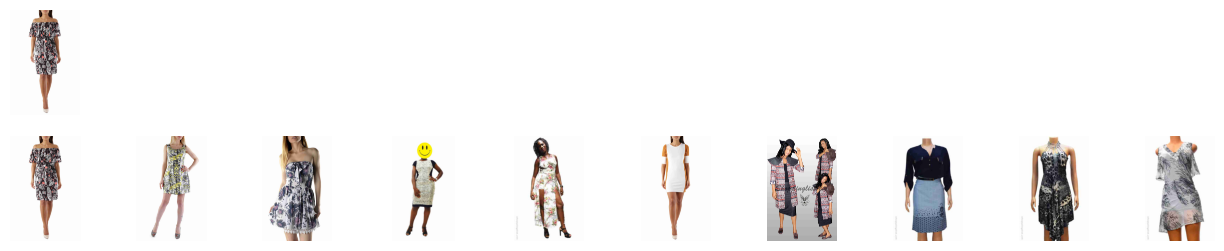

In [17]:
make_recommendations(item_id=7541)

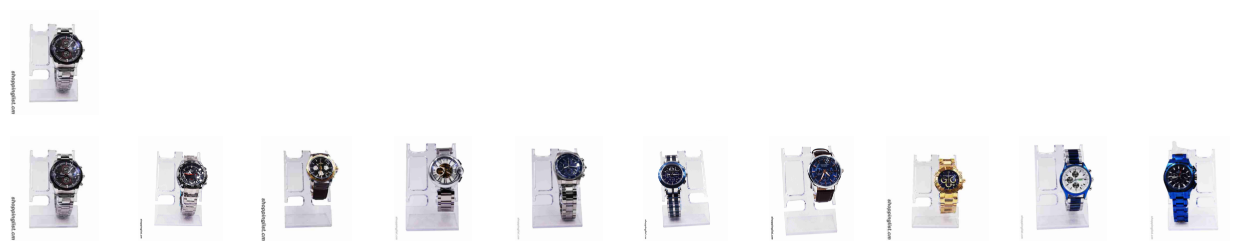

In [18]:
make_recommendations(item_id=6214)

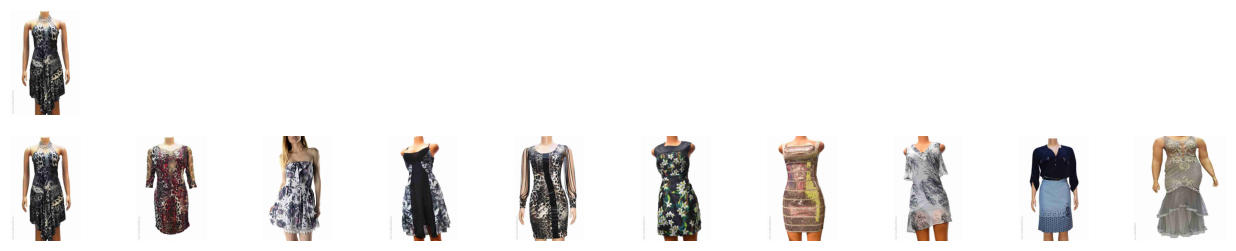

In [19]:
make_recommendations(item_id=5817)

### Example with and without filter

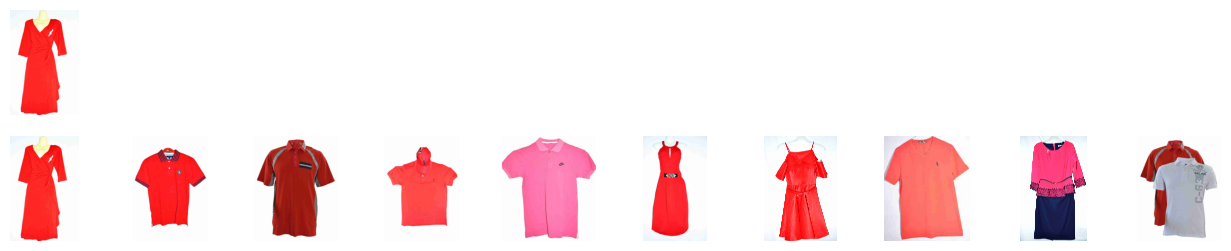

In [20]:
make_recommendations(item_id=1087)

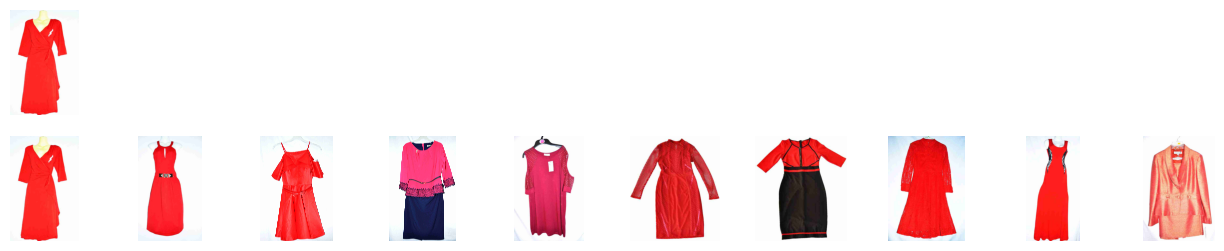

In [21]:
make_recommendations(item_id=1087, apply_filter=True)

In [22]:
import random
def random_item_search():
    # randomly select an item
    random_item_id = random.choice(item_ids)
    print(f"item id: {random_item_id}")

    # run the knn_search for the query item
    item, knns = knn_search(item_id=random_item_id)

    # display the results.
    display_knn(knns, ref_item=item)

item id: 6171


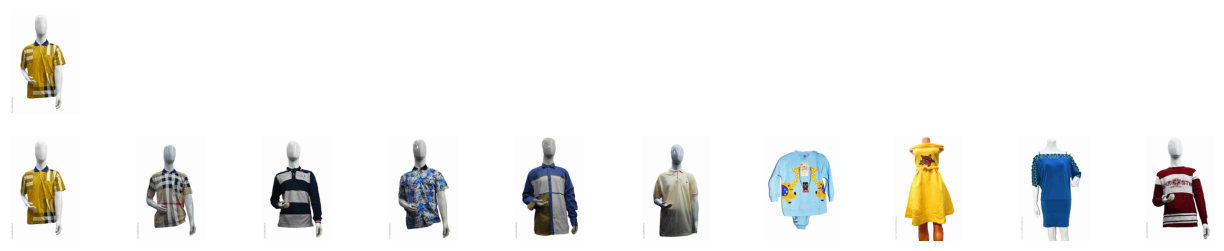

In [26]:
# explore other recommendations
random_item_search()

## Image-based Search Engine

In [27]:
img_paths = [os.path.join(DATASET_DIR, 'img1.jpg')]

img_vectors = extract_embeddings_batch(paths=img_paths)

In [28]:
def image_based_search(src_vector, k=10, num_candidates=100):

    # build the knn query. Add filter on category if apply_filter is enable
    knn_query = {
        "knn": {
            "field": "image_features",
            "query_vector": src_vector,
            "k": k,
            "num_candidates": num_candidates
        }
    }
        
    # execute the knn query
    res = es.search(index=index_name, query=knn_query)
    knn_results = res['hits']['hits']
    return knn_results

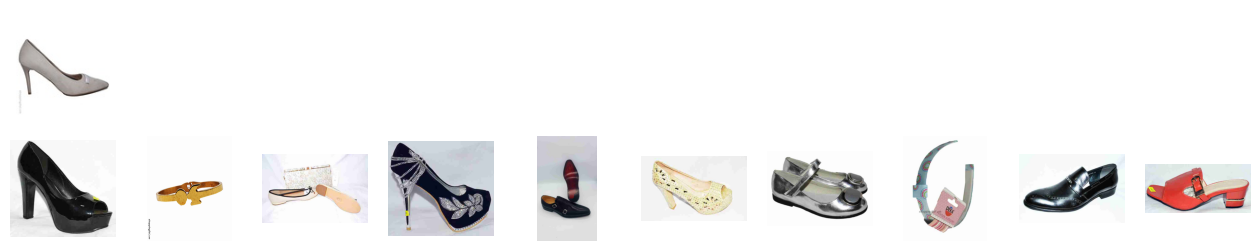

In [29]:
knn_results = image_based_search(img_vectors[0])
display_knn(knn_items=knn_results, src_img_path=img_paths[0])

### Author
Carmel WENGA, Data & ML Engineer
- [Medium](https://medium.com/@carmelwenga)
- [LinkedIn](https://www.linkedin.com/in/carmel-christian-wenga-871876178/)